In [311]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.svm import SVR

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [312]:
df = pd.read_csv('cars_data (1).csv')

In [313]:
df.head()

,Brand,Year,Mileage,Engine_Size,Fuel_Type,Transmission,Previous_Owners,Price
0,Kia,2015.0,110373.0,2.5,Electric,Manual,2,3000.0
1,Mercedes,2010.0,186144.0,1.3,Electric,Manual,5,4844.0
2,Nissan,2018.0,29574.0,2.6,Petrol,Manual,1,6628.0
3,Kia,2010.0,139502.0,2.4,Diesel,Automatic,NaN,3000.0
4,BMW,2014.0,148748.0,3.5,Diesel,Manual,1,6451.0


In [314]:
df.shape

(1000, 8)

In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            979 non-null    object 
 1   Year             974 non-null    float64
 2   Mileage          979 non-null    float64
 3   Engine_Size      964 non-null    float64
 4   Fuel_Type        982 non-null    object 
 5   Transmission     962 non-null    object 
 6   Previous_Owners  950 non-null    object 
 7   Price            987 non-null    float64
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


In [316]:
df.isnull().sum()

Brand              21
Year               26
Mileage            21
Engine_Size        36
Fuel_Type          18
Transmission       38
Previous_Owners    50
Price              13
dtype: int64

In [317]:
for col in df.columns:
    
    if df[col].dtype != 'object':
        
        df[col] = df[col].fillna(df[col].median())
    
    else:
        
        df[col] = df[col].fillna(df[col].mode()[0])

In [318]:
df.drop_duplicates(inplace=True)

In [319]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    
    df[col] = le.fit_transform(df[col])

In [320]:
df.columns

Index(['Brand', 'Year', 'Mileage', 'Engine_Size', 'Fuel_Type', 'Transmission',
       'Previous_Owners', 'Price'],
      dtype='object')

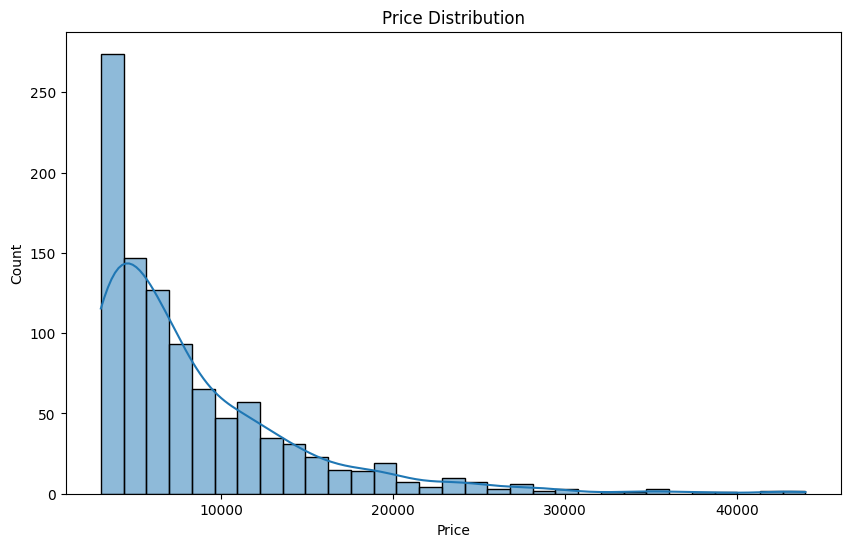

In [321]:
plt.figure(figsize=(10,6))

sns.histplot(df['Price'], kde=True)

plt.title('Price Distribution')

plt.show()

In [322]:
Q1 = df['Price'].quantile(0.25)

Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[
    (df['Price'] >= lower) &
    (df['Price'] <= upper)
]

In [323]:
X = df.drop('Price', axis=1)

y = df['Price']

In [324]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [325]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [326]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    lin_reg,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print(scores)

print("Mean R2 Score :")

print(scores.mean())

[0.50494777 0.45473379 0.48120133 0.38727489 0.448339  ]
Mean R2 Score :
0.4552993581063657


In [327]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [328]:
from sklearn.neighbors import KNeighborsRegressor

from sklearn.linear_model import LinearRegression

from sklearn.svm import SVR

In [329]:
knn_reg = KNeighborsRegressor(
    n_neighbors=3,
    weights='distance'
)

knn_reg.fit(X_train, y_train)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [330]:
y_pred_knn = knn_reg.predict(X_test)

In [331]:
print("KNN R2 Score :")

print(r2_score(y_test, y_pred_knn))

KNN R2 Score :
0.44491014417054453


In [332]:
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [333]:
y_pred_lin = lin_reg.predict(X_test)

In [334]:
print("Linear Regression R2 Score :")

print(r2_score(y_test, y_pred_lin))

Linear Regression R2 Score :
0.5049477726255623


In [335]:
svr = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1
)

svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [336]:
y_pred_svr = svr.predict(X_test)

In [337]:
print("SVR R2 Score :")

print(r2_score(y_test, y_pred_svr))

SVR R2 Score :
0.251657424773292


In [338]:
reg_models = pd.DataFrame({

    'Model': [
        'KNN Regressor',
        'Linear Regression',
        'SVR'
    ],

    'R2 Score': [

        r2_score(y_test, y_pred_knn),

        r2_score(y_test, y_pred_lin),

        r2_score(y_test, y_pred_svr)
    ]
})

reg_models

,Model,R2 Score
0,KNN Regressor,0.444910
1,Linear Regression,0.504948
2,SVR,0.251657


In [339]:
bins = [
    0,
    15000,
    30000,
    50000,
    100000
]

labels = [
    'Low',
    'Medium',
    'High',
    'Luxury'
]

df['Price_Category'] = pd.cut(
    df['Price'],
    bins=bins,
    labels=labels
)

In [340]:
df['Price_Category'].value_counts()

Price_Category
Low       879
Medium     71
High        0
Luxury      0
Name: count, dtype: int64

In [341]:
X_cls = df.drop(
    ['Price', 'Price_Category'],
    axis=1
)

y_cls = df['Price_Category']

In [342]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

In [343]:
scaler = StandardScaler()

X_train_cls = scaler.fit_transform(X_train_cls)

X_test_cls = scaler.transform(X_test_cls)

In [344]:
knn_cls = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

knn_cls.fit(X_train_cls, y_train_cls)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [345]:
y_pred_knn_cls = knn_cls.predict(X_test_cls)

In [346]:
print("KNN Accuracy :")

print(accuracy_score(y_test_cls, y_pred_knn_cls))

KNN Accuracy :
0.9210526315789473


In [347]:
nb = GaussianNB()

nb.fit(X_train_cls, y_train_cls)

,priors,None
,var_smoothing,1e-09


In [348]:
y_pred_nb = nb.predict(X_test_cls)

In [349]:
print("Naive Bayes Accuracy :")

print(accuracy_score(y_test_cls, y_pred_nb))

Naive Bayes Accuracy :
0.9263157894736842


In [350]:
log_model = LogisticRegression(
    max_iter=2000
)

log_model.fit(X_train_cls, y_train_cls)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [351]:
y_pred_log = log_model.predict(X_test_cls)

In [352]:
print("Logistic Regression Accuracy :")

print(accuracy_score(y_test_cls, y_pred_log))

Logistic Regression Accuracy :
0.9263157894736842


In [353]:
svm_cls = SVC(
    kernel='rbf',
    C=10
)

svm_cls.fit(X_train_cls, y_train_cls)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [354]:
y_pred_svm = svm_cls.predict(X_test_cls)

In [355]:
print("SVM Accuracy :")

print(accuracy_score(y_test_cls, y_pred_svm))

SVM Accuracy :
0.9368421052631579


In [356]:
cls_models = pd.DataFrame({

    'Model': [
        'KNN',
        'Naive Bayes',
        'Logistic Regression',
        'SVM'
    ],

    'Accuracy': [

        accuracy_score(y_test_cls, y_pred_knn_cls),

        accuracy_score(y_test_cls, y_pred_nb),

        accuracy_score(y_test_cls, y_pred_log),

        accuracy_score(y_test_cls, y_pred_svm)
    ]
})

cls_models

,Model,Accuracy
0,KNN,0.921053
1,Naive Bayes,0.926316
2,Logistic Regression,0.926316
3,SVM,0.936842


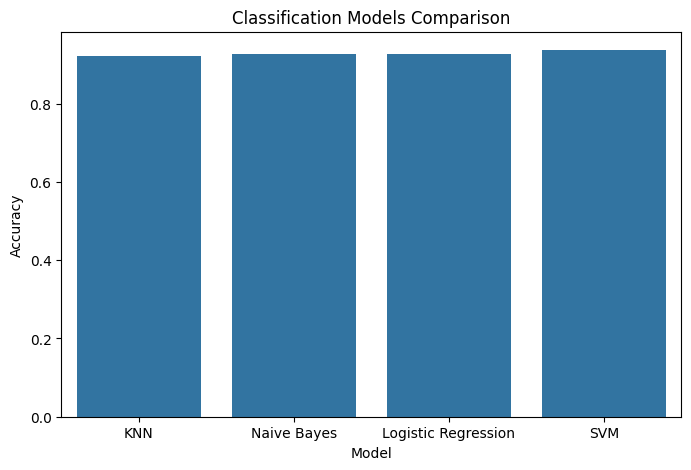

In [357]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=cls_models
)

plt.title('Classification Models Comparison')

plt.show()

In [358]:
from sklearn.ensemble import ExtraTreesRegressor

In [359]:
et = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

et.fit(X_train, y_train)

y_pred_et = et.predict(X_test)

print("Extra Trees R2 Score :")

print(r2_score(y_test, y_pred_et))

Extra Trees R2 Score :
0.6926565556902118


In [360]:
from sklearn.ensemble import RandomForestRegressor

In [361]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2 Score :")

print(r2_score(y_test, y_pred_rf))

Random Forest R2 Score :
0.7219447739205567


In [362]:
models = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'KNN',
        'SVR',
        'Extra Trees',
        'Random Forest'
    ],

    'R2 Score': [

        r2_score(y_test, y_pred_lin),

        r2_score(y_test, y_pred_knn),

        r2_score(y_test, y_pred_svr),

        r2_score(y_test, y_pred_et),

        r2_score(y_test, y_pred_rf)
    ]
})

models

,Model,R2 Score
0,Linear Regression,0.504948
1,KNN,0.444910
2,SVR,0.251657
3,Extra Trees,0.692657
4,Random Forest,0.721945


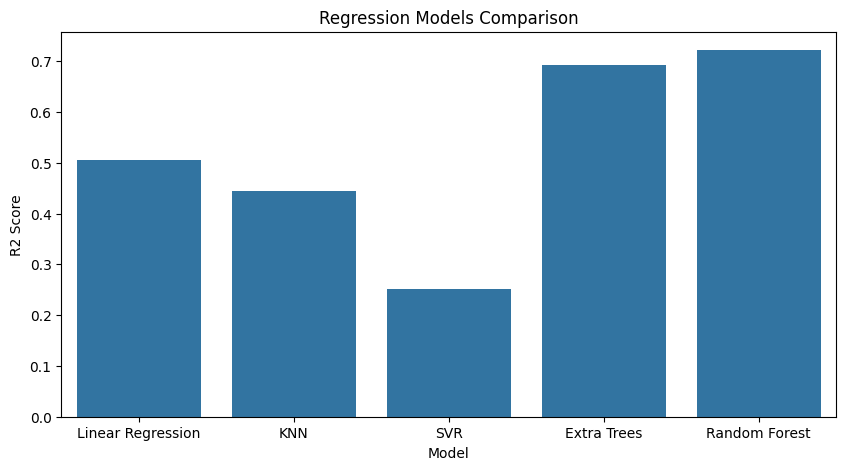

In [363]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=models
)

plt.title('Regression Models Comparison')

plt.show()

In [364]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [365]:
y_pred_gb = gb.predict(X_test)

In [366]:
print("Gradient Boosting R2 Score :")

print(r2_score(y_test, y_pred_gb))

Gradient Boosting R2 Score :
0.8037131337917887


In [367]:
models = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'KNN',
        'SVR',
        'Random Forest',
        'Gradient Boosting'
    ],

    'R2 Score': [

        r2_score(y_test, y_pred_lin),

        r2_score(y_test, y_pred_knn),

        r2_score(y_test, y_pred_svr),

        r2_score(y_test, y_pred_rf),

        r2_score(y_test, y_pred_gb)
    ]
})

models

,Model,R2 Score
0,Linear Regression,0.504948
1,KNN,0.444910
2,SVR,0.251657
3,Random Forest,0.721945
4,Gradient Boosting,0.803713


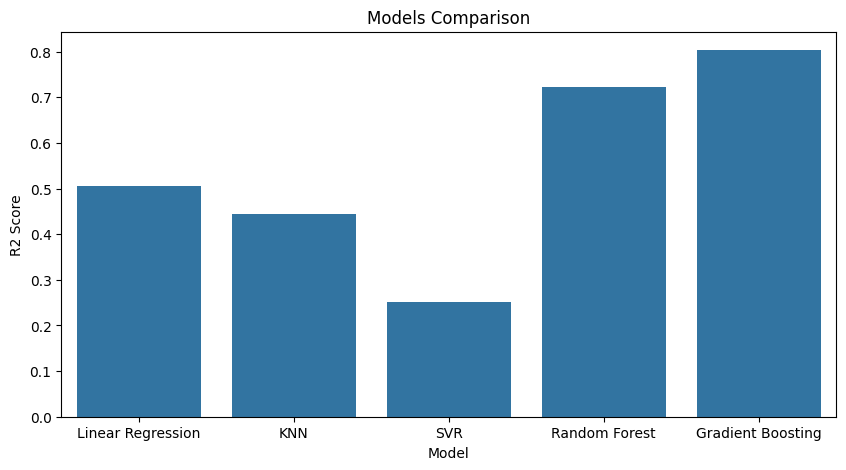

In [368]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=models
)

plt.title('Models Comparison')

plt.show()

In [369]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [370]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,Year,0.291148
0,Brand,0.273850
2,Mileage,0.254442
3,Engine_Size,0.077215
4,Fuel_Type,0.058099
6,Previous_Owners,0.028591
5,Transmission,0.016656


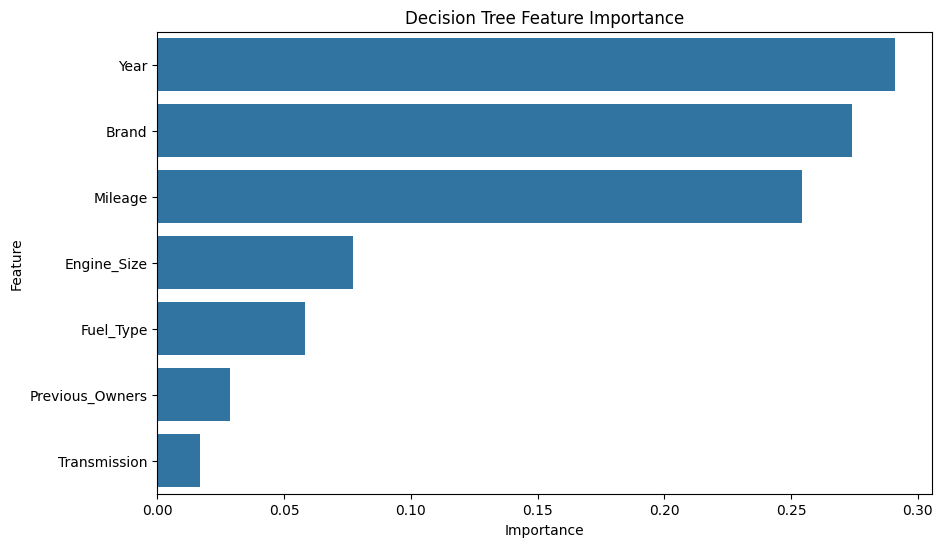

In [371]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Decision Tree Feature Importance')

plt.show()

In [372]:
selected_features = importance[
    importance['Importance'] > 0.02
]

selected_features

,Feature,Importance
1,Year,0.291148
0,Brand,0.273850
2,Mileage,0.254442
3,Engine_Size,0.077215
4,Fuel_Type,0.058099
6,Previous_Owners,0.028591


In [373]:
important_cols = selected_features['Feature']

X = df[important_cols]

y = df['Price']

In [374]:
from sklearn.model_selection import GridSearchCV

In [375]:
param_grid = {

    'n_estimators': [100, 200, 300],

    'max_depth': [5, 10, 15],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]
}

In [376]:
grid_rf = GridSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1
)

In [377]:
grid_rf.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [378]:
print("Best Parameters :")

print(grid_rf.best_params_)

Best Parameters :
{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [379]:
print("Best R2 Score :")

print(grid_rf.best_score_)

Best R2 Score :
0.7175138178638547


In [380]:
best_rf = grid_rf.best_estimator_

y_pred_best = best_rf.predict(X_test)

print(r2_score(y_test, y_pred_best))

0.7378036385030773


In [381]:
from sklearn.model_selection import RandomizedSearchCV

In [382]:
param_dist = {

    'n_estimators': [100, 200, 300, 500],

    'max_depth': [5, 10, 15, 20],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4]
}

In [383]:
random_rf = RandomizedSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_distributions=param_dist,

    n_iter=10,

    cv=5,

    scoring='r2',

    random_state=42,

    n_jobs=-1
)

In [384]:
random_rf.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [385]:
print("Best Parameters :")

print(random_rf.best_params_)

Best Parameters :
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10}


In [386]:
print("Best Cross Validation Score :")

print(random_rf.best_score_)

Best Cross Validation Score :
0.6963874976740749


In [387]:
best_rf = random_rf.best_estimator_

y_pred_random = best_rf.predict(X_test)

print(r2_score(y_test, y_pred_random))

0.7302772184587312


In [388]:
from sklearn.ensemble import AdaBoostRegressor

In [389]:
ada = AdaBoostRegressor(

    n_estimators=200,

    learning_rate=0.05,

    random_state=42
)

In [390]:
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print("AdaBoost R2 Score :")

print(r2_score(y_test, y_pred_ada))

AdaBoost R2 Score :
0.5823112489277525


In [ ]:
models = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'KNN',
        'SVR',
        'Random Forest',
        'AdaBoost'
    ],

    'R2 Score': [

        r2_score(y_test, y_pred_lin),

        r2_score(y_test, y_pred_knn),

        r2_score(y_test, y_pred_svr),

        r2_score(y_test, y_pred_rf),

        r2_score(y_test, y_pred_ada)
    ]
})

models

,Model,R2 Score
0,Linear Regression,0.504948
1,KNN,0.444910
2,SVR,0.251657
3,Random Forest,0.721945
4,AdaBoost,0.582311
